<a href="https://colab.research.google.com/github/AyeshaJalil/AI-ML-Engineering-Internship-Tasks/blob/main/Task_5_Auto_Tagging_Support_Tickets/Auto_Tagging_Support_Tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q transformers datasets evaluate accelerate sentencepiece scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [5]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [6]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets.csv


In [8]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [9]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [11]:
print(df.isnull().sum())

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [12]:
pd.set_option("display.max_colwidth", 200)

df.head(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email a...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the origin...",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacte...",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond. To remove the new {product_purch I've ...",Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,"I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account?...",Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,"I'm having an issue with the {product_purchased}. Please assist. (Thanks) I will contact all my suppliers and confirm.\n\nPlease try and find out whether their inventory is currently stocked, or a...",Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,"I'm having an issue with the {product_purchased}. Please assist. Thank you.\n\n{product_purchased} is not the exact type you might prefer, they use the exact same method for different uses. Please...",Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,"My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Ca

In [13]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

# Select the required columns
tickets_df = df[
    ["Ticket Subject", "Ticket Description", "Ticket Type"]
].copy()

# Remove rows with missing values
tickets_df = tickets_df.dropna(
    subset=["Ticket Subject", "Ticket Description", "Ticket Type"]
)

# Combine subject and description into one text field
tickets_df["text"] = (
    tickets_df["Ticket Subject"].astype(str).str.strip()
    + ". "
    + tickets_df["Ticket Description"].astype(str).str.strip()
)

# Create the target label column
tickets_df["label"] = tickets_df["Ticket Type"].astype(str).str.strip()

# Keep only the required columns
tickets_df = tickets_df[["text", "label"]]

# Remove empty rows and duplicates
tickets_df = tickets_df[
    (tickets_df["text"] != "") &
    (tickets_df["label"] != "")
]

tickets_df = tickets_df.drop_duplicates().reset_index(drop=True)

print("Prepared dataset shape:", tickets_df.shape)

tickets_df.head()

Prepared dataset shape: (8427, 2)


,text,label
0,Product setup. I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double che...,Technical issue
1,Peripheral compatibility. I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please...,Technical issue
2,"Network problem. I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm...",Technical issue
3,"Account access. I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've ...",Billing inquiry
4,Data loss. I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please ha...,Billing inquiry


In [14]:
print("Number of unique tags:", tickets_df["label"].nunique())

print("\nAvailable tags:")
print(tickets_df["label"].unique())

Number of unique tags: 5

Available tags:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [15]:
print("Tickets per category:")
print(tickets_df["label"].value_counts())

Tickets per category:
label
Refund request          1740
Technical issue         1735
Cancellation request    1681
Product inquiry         1639
Billing inquiry         1632
Name: count, dtype: int64


In [16]:
tickets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8427 entries, 0 to 8426
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8427 non-null   object
 1   label   8427 non-null   object
dtypes: object(2)
memory usage: 131.8+ KB


In [17]:
from sklearn.model_selection import train_test_split

# Split the dataset: 80% training and 20% testing
train_df, test_df = train_test_split(
    tickets_df,
    test_size=0.20,
    random_state=42,
    stratify=tickets_df["label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 6741
Testing samples: 1686


In [18]:
print("Training category distribution:")
print(train_df["label"].value_counts())

print("\nTesting category distribution:")
print(test_df["label"].value_counts())

Training category distribution:
label
Refund request          1392
Technical issue         1388
Cancellation request    1345
Product inquiry         1311
Billing inquiry         1305
Name: count, dtype: int64

Testing category distribution:
label
Refund request          348
Technical issue         347
Cancellation request    336
Product inquiry         328
Billing inquiry         327
Name: count, dtype: int64


In [19]:
candidate_tags = sorted(tickets_df["label"].unique().tolist())

print("Candidate tags:")
for tag in candidate_tags:
    print("-", tag)

Candidate tags:
- Billing inquiry
- Cancellation request
- Product inquiry
- Refund request
- Technical issue


In [20]:
print("Ticket text:")
print(test_df.loc[0, "text"])

print("\nActual tag:")
print(test_df.loc[0, "label"])

Ticket text:
Installation support. I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account?

What do I do if I want to restore my $19 retail version of my I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?

Actual tag:
Cancellation request


In [21]:
import torch
from transformers import pipeline

# Use GPU when available
device = 0 if torch.cuda.is_available() else -1

print("Device:", "GPU" if device == 0 else "CPU")
print("Loading zero-shot model...")

zero_shot_classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

print("Zero-shot model loaded successfully.")

Device: GPU
Loading zero-shot model...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Zero-shot model loaded successfully.


In [22]:
candidate_tags = sorted(tickets_df["label"].unique().tolist())

print("Candidate tags:")

for tag in candidate_tags:
    print("-", tag)

Candidate tags:
- Billing inquiry
- Cancellation request
- Product inquiry
- Refund request
- Technical issue


In [23]:
sample_ticket = test_df.loc[0, "text"]
actual_tag = test_df.loc[0, "label"]

result = zero_shot_classifier(
    sample_ticket,
    candidate_labels=candidate_tags,
    hypothesis_template="This customer support ticket is about {}.",
    multi_label=False
)

print("Ticket:")
print(sample_ticket)

print("\nActual tag:")
print(actual_tag)

print("\nTop 3 predicted tags:")

for rank, (tag, score) in enumerate(
    zip(result["labels"][:3], result["scores"][:3]),
    start=1
):
    print(f"{rank}. {tag}: {score:.4f}")

Ticket:
Installation support. I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account?

What do I do if I want to restore my $19 retail version of my I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?

Actual tag:
Cancellation request

Top 3 predicted tags:
1. Product inquiry: 0.4624
2. Technical issue: 0.2720
3. Billing inquiry: 0.1238


In [24]:
zero_shot_top3 = pd.DataFrame({
    "Predicted Tag": result["labels"][:3],
    "Probability": result["scores"][:3]
})

zero_shot_top3.index = ["Top 1", "Top 2", "Top 3"]

zero_shot_top3

,Predicted Tag,Probability
Top 1,Product inquiry,0.462389
Top 2,Technical issue,0.272030
Top 3,Billing inquiry,0.123802


In [25]:
# Select the same 200 tickets every time
evaluation_size = min(200, len(test_df))

zero_eval_df = test_df.sample(
    n=evaluation_size,
    random_state=42
).reset_index(drop=True)

print("Tickets selected for evaluation:", len(zero_eval_df))

Tickets selected for evaluation: 200


In [26]:
import torch
from tqdm.auto import tqdm

# Use a small batch on CPU and a larger batch on GPU
batch_size = 8 if torch.cuda.is_available() else 2

# Limit extremely long ticket descriptions
ticket_texts = (
    zero_eval_df["text"]
    .astype(str)
    .str.slice(0, 1200)
    .tolist()
)

zero_shot_outputs = []

for start in tqdm(
    range(0, len(ticket_texts), batch_size),
    desc="Classifying tickets"
):
    batch_texts = ticket_texts[start:start + batch_size]

    batch_results = zero_shot_classifier(
        batch_texts,
        candidate_labels=candidate_tags,
        hypothesis_template="This customer support ticket is about {}.",
        multi_label=False,
        truncation=True
    )

    # Ensure the result is always a list
    if isinstance(batch_results, dict):
        batch_results = [batch_results]

    zero_shot_outputs.extend(batch_results)

print("Predictions completed:", len(zero_shot_outputs))

Classifying tickets:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Predictions completed: 200


In [27]:
zero_shot_results = []

for index, result in enumerate(zero_shot_outputs):
    zero_shot_results.append({
        "Ticket": zero_eval_df.loc[index, "text"],
        "Actual Tag": zero_eval_df.loc[index, "label"],

        "Top 1 Tag": result["labels"][0],
        "Top 1 Score": result["scores"][0],

        "Top 2 Tag": result["labels"][1],
        "Top 2 Score": result["scores"][1],

        "Top 3 Tag": result["labels"][2],
        "Top 3 Score": result["scores"][2]
    })

zero_shot_results_df = pd.DataFrame(zero_shot_results)

zero_shot_results_df.head(10)

,Ticket,Actual Tag,Top 1 Tag,Top 1 Score,Top 2 Tag,Top 2 Score,Top 3 Tag,Top 3 Score
0,"Product compatibility. I'm having an issue with the {product_purchased}. Please assist. I've tried different settings and configurations on my {product_purchased}, but the issue persists.",Cancellation request,Product inquiry,0.793245,Technical issue,0.161372,Billing inquiry,0.018952
1,"Network problem. I'm having an issue with the {product_purchased}. Please assist.\n\nI need a product that is perfect for me, and I want to sell you something special, or to sell you something nic...",Cancellation request,Product inquiry,0.527937,Technical issue,0.283062,Billing inquiry,0.104794
2,"Network problem. I'm having an issue with the {product_purchased}. Please assist. Thank you for your assistance. I've already contacted customer support multiple times, but the issue remains unres...",Cancellation request,Product inquiry,0.750310,Technical issue,0.169720,Billing inquiry,0.038679
3,"Display issue. I've recently set up my {product_purchased}, but it fails to connect to any available networks. What steps should I take to troubleshoot this issue?\n\nIf you're the user that's usi...",Refund request,Product inquiry,0.504433,Technical issue,0.338945,Billing inquiry,0.079865
4,Product recommendation. I'm having an issue with the {product_purchased}. Please assist.\n\nCoupon code 1F0E3E-6C6F-4E6C-8BE9-B4F6C28 I'm not sure if this issue is specific to my device or if othe...,Refund request,Product inquiry,0.694635,Technical issue,0.192511,Billing inquiry,0.047765
5,"Refund request. There seems to be a hardware problem with my {product_purchased}. The screen is flickering, and I'm unable to use it. What should I do?\n\nThe solution to this could be to create a...",Billing inquiry,Refund request,0.696623,Product inquiry,0.132044,Technical issue,0.073431
6,Account access. I'm having an issue with the {product_purchased}. Please assist.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nMy #{ProductID} is not an ID: I've tried cle...,Cancellation request,Product inquiry,0.662231,Technical issue,0.167312,Billing inquiry,0.072415
7,"Product recommendation. I'm having an issue with the {product_purchased}. Please assist.\n\n}\n\n}\n\n}\n\n$curl -q br-refresh\n\n-l ""{""\n\nif $curl - This problem started occurring after the rece...",Technical issue,Product inquiry,0.651995,Technical issue,0.218605,Billing inquiry,0.056324
8,Battery life. I'm having an issue with the {product_purchased}. Please assist.\n\nHow do I get a refund for my purchase?\n\nTo access this information and submit an e-mail to the seller you need a...,Refund request,Refund request,0.509224,Product inquiry,0.267937,Technical issue,0.089003
9,Account access. I've encountered a data loss issue with my {product_purchased}. All the files and documents seem to have disappeared. Can you guide me on how to retrieve them? I'm not able to do t...,Technical issue,Product inquiry,0.860584,Technical issue,0.075637,Billing inquiry,0.026995


In [28]:
from sklearn.metrics import accuracy_score, f1_score

actual_labels = zero_shot_results_df["Actual Tag"]
predicted_labels = zero_shot_results_df["Top 1 Tag"]

zero_shot_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

zero_shot_f1 = f1_score(
    actual_labels,
    predicted_labels,
    average="weighted"
)

top3_correct = zero_shot_results_df.apply(
    lambda row: row["Actual Tag"] in [
        row["Top 1 Tag"],
        row["Top 2 Tag"],
        row["Top 3 Tag"]
    ],
    axis=1
)

zero_shot_top3_accuracy = top3_correct.mean()

print("ZERO-SHOT RESULTS")
print("-----------------------------")
print(f"Top-1 Accuracy: {zero_shot_accuracy:.4f}")
print(f"Weighted F1-score: {zero_shot_f1:.4f}")
print(f"Top-3 Accuracy: {zero_shot_top3_accuracy:.4f}")

ZERO-SHOT RESULTS
-----------------------------
Top-1 Accuracy: 0.1850
Weighted F1-score: 0.1017
Top-3 Accuracy: 0.5800


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        labels=candidate_tags,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.00      0.00      0.00        26
Cancellation request       0.11      0.02      0.04        47
     Product inquiry       0.20      0.77      0.32        43
      Refund request       0.05      0.03      0.03        39
     Technical issue       0.50      0.04      0.08        45

            accuracy                           0.18       200
           macro avg       0.17      0.17      0.09       200
        weighted avg       0.19      0.18      0.10       200



In [30]:
zero_shot_results_df.to_csv(
    "zero_shot_results.csv",
    index=False
)

print("Saved as zero_shot_results.csv")

Saved as zero_shot_results.csv


In [32]:
few_shot_examples = (
    train_df.groupby("label", group_keys=False)
    .sample(n=1, random_state=42)
    [["text", "label"]]
    .reset_index(drop=True)
)

print("Few-shot examples:")
few_shot_examples

Few-shot examples:


,text,label
0,Delivery problem. I'm having an issue with the {product_purchased}. Please assist.\n\nHere comes the update in regards to the [v1.01] release.\n\nTo make sure any errors that you see during the tr...,Billing inquiry
1,Refund request. I'm having an issue with the {product_purchased}. Please assist.\n\n#3.1 Product Purchase & Buyback Requests\n\nSophie (926) 993-5534\n\npdp=h I've tried different settings and con...,Cancellation request
2,Data loss. I'm having an issue with the {product_purchased}. Please assist.\n\nWe may have some information about this issue that you do not have\n\nThe product description says that after we rece...,Product inquiry
3,Payment issue. I'm having an issue with the {product_purchased}. Please assist. We use multiple versions of this product. The version you have is the one that was purchased and shipped. If you ord...,Refund request
4,Software bug. I'm having an issue with the {product_purchased}. Please assist.\n\n\nThank you.\n\nSale\n\n\nS-G\n\nPSN: _________________PSN: x3_3 I've recently updated the firmware of my {product...,Technical issue


In [33]:
def create_few_shot_prompt(ticket_text):
    prompt = (
        "Classify the final customer support ticket using one of these categories:\n"
        + ", ".join(candidate_tags)
        + "\n\nHere are some labeled examples:\n\n"
    )

    for index, row in few_shot_examples.iterrows():
        example_text = str(row["text"])[:250]

        prompt += (
            f"Example {index + 1}\n"
            f"Ticket: {example_text}\n"
            f"Category: {row['label']}\n\n"
        )

    prompt += (
        "Now classify this ticket:\n"
        f"Ticket: {str(ticket_text)[:600]}\n"
    )

    return prompt

In [34]:
sample_ticket = test_df.loc[0, "text"]
actual_tag = test_df.loc[0, "label"]

few_shot_prompt = create_few_shot_prompt(sample_ticket)

few_shot_result = zero_shot_classifier(
    few_shot_prompt,
    candidate_labels=candidate_tags,
    hypothesis_template="The correct category for the final ticket is {}.",
    multi_label=False,
    truncation=True
)

print("Ticket:")
print(sample_ticket)

print("\nActual tag:")
print(actual_tag)

print("\nFew-shot top 3 predicted tags:")

for rank, (tag, score) in enumerate(
    zip(
        few_shot_result["labels"][:3],
        few_shot_result["scores"][:3]
    ),
    start=1
):
    print(f"{rank}. {tag}: {score:.4f}")

Ticket:
Installation support. I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account?

What do I do if I want to restore my $19 retail version of my I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?

Actual tag:
Cancellation request

Few-shot top 3 predicted tags:
1. Billing inquiry: 0.2943
2. Product inquiry: 0.2219
3. Technical issue: 0.1948


In [36]:
if "zero_eval_df" not in globals():
    evaluation_size = min(200, len(test_df))

    zero_eval_df = test_df.sample(
        n=evaluation_size,
        random_state=42
    ).reset_index(drop=True)

print("Evaluation tickets:", len(zero_eval_df))

Evaluation tickets: 200


In [37]:
from tqdm.auto import tqdm

few_shot_outputs = []

for ticket in tqdm(
    zero_eval_df["text"].tolist(),
    desc="Few-shot classification"
):
    prompt = create_few_shot_prompt(ticket)

    result = zero_shot_classifier(
        prompt,
        candidate_labels=candidate_tags,
        hypothesis_template="The correct category for the final ticket is {}.",
        multi_label=False,
        truncation=True
    )

    few_shot_outputs.append(result)

print("Few-shot predictions completed.")

Few-shot classification:   0%|          | 0/200 [00:00<?, ?it/s]

Few-shot predictions completed.


In [38]:
few_shot_results = []

for index, result in enumerate(few_shot_outputs):
    few_shot_results.append({
        "Ticket": zero_eval_df.loc[index, "text"],
        "Actual Tag": zero_eval_df.loc[index, "label"],

        "Top 1 Tag": result["labels"][0],
        "Top 1 Score": result["scores"][0],

        "Top 2 Tag": result["labels"][1],
        "Top 2 Score": result["scores"][1],

        "Top 3 Tag": result["labels"][2],
        "Top 3 Score": result["scores"][2]
    })

few_shot_results_df = pd.DataFrame(few_shot_results)

few_shot_results_df.head(10)

,Ticket,Actual Tag,Top 1 Tag,Top 1 Score,Top 2 Tag,Top 2 Score,Top 3 Tag,Top 3 Score
0,"Product compatibility. I'm having an issue with the {product_purchased}. Please assist. I've tried different settings and configurations on my {product_purchased}, but the issue persists.",Cancellation request,Billing inquiry,0.264311,Product inquiry,0.232527,Refund request,0.208854
1,"Network problem. I'm having an issue with the {product_purchased}. Please assist.\n\nI need a product that is perfect for me, and I want to sell you something special, or to sell you something nic...",Cancellation request,Technical issue,0.262613,Billing inquiry,0.220362,Product inquiry,0.192317
2,"Network problem. I'm having an issue with the {product_purchased}. Please assist. Thank you for your assistance. I've already contacted customer support multiple times, but the issue remains unres...",Cancellation request,Billing inquiry,0.258662,Refund request,0.235702,Technical issue,0.193122
3,"Display issue. I've recently set up my {product_purchased}, but it fails to connect to any available networks. What steps should I take to troubleshoot this issue?\n\nIf you're the user that's usi...",Refund request,Billing inquiry,0.254058,Technical issue,0.253393,Product inquiry,0.187385
4,Product recommendation. I'm having an issue with the {product_purchased}. Please assist.\n\nCoupon code 1F0E3E-6C6F-4E6C-8BE9-B4F6C28 I'm not sure if this issue is specific to my device or if othe...,Refund request,Billing inquiry,0.279843,Product inquiry,0.249290,Technical issue,0.202091
5,"Refund request. There seems to be a hardware problem with my {product_purchased}. The screen is flickering, and I'm unable to use it. What should I do?\n\nThe solution to this could be to create a...",Billing inquiry,Refund request,0.399780,Technical issue,0.193591,Billing inquiry,0.166963
6,Account access. I'm having an issue with the {product_purchased}. Please assist.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nMy #{ProductID} is not an ID: I've tried cle...,Cancellation request,Billing inquiry,0.242954,Product inquiry,0.237201,Technical issue,0.211590
7,"Product recommendation. I'm having an issue with the {product_purchased}. Please assist.\n\n}\n\n}\n\n}\n\n$curl -q br-refresh\n\n-l ""{""\n\nif $curl - This problem started occurring after the rece...",Technical issue,Billing inquiry,0.253601,Technical issue,0.227336,Product inquiry,0.207692
8,Battery life. I'm having an issue with the {product_purchased}. Please assist.\n\nHow do I get a refund for my purchase?\n\nTo access this information and submit an e-mail to the seller you need a...,Refund request,Refund request,0.259660,Technical issue,0.248811,Billing inquiry,0.239425
9,Account access. I've encountered a data loss issue with my {product_purchased}. All the files and documents seem to have disappeared. Can you guide me on how to retrieve them? I'm not able to do t...,Technical issue,Technical issue,0.243358,Billing inquiry,0.236988,Product inquiry,0.192580


In [39]:
from sklearn.metrics import accuracy_score, f1_score

few_actual = few_shot_results_df["Actual Tag"]
few_predicted = few_shot_results_df["Top 1 Tag"]

few_shot_accuracy = accuracy_score(
    few_actual,
    few_predicted
)

few_shot_f1 = f1_score(
    few_actual,
    few_predicted,
    average="weighted"
)

few_shot_top3_correct = few_shot_results_df.apply(
    lambda row: row["Actual Tag"] in [
        row["Top 1 Tag"],
        row["Top 2 Tag"],
        row["Top 3 Tag"]
    ],
    axis=1
)

few_shot_top3_accuracy = few_shot_top3_correct.mean()

print("FEW-SHOT RESULTS")
print("-----------------------------")
print(f"Top-1 Accuracy: {few_shot_accuracy:.4f}")
print(f"Weighted F1-score: {few_shot_f1:.4f}")
print(f"Top-3 Accuracy: {few_shot_top3_accuracy:.4f}")

FEW-SHOT RESULTS
-----------------------------
Top-1 Accuracy: 0.1600
Weighted F1-score: 0.1249
Top-3 Accuracy: 0.5450


In [40]:
comparison_data = []

if "zero_shot_accuracy" in globals():
    comparison_data.append({
        "Method": "Zero-shot",
        "Top-1 Accuracy": zero_shot_accuracy,
        "Weighted F1-score": zero_shot_f1,
        "Top-3 Accuracy": zero_shot_top3_accuracy
    })

comparison_data.append({
    "Method": "Few-shot",
    "Top-1 Accuracy": few_shot_accuracy,
    "Weighted F1-score": few_shot_f1,
    "Top-3 Accuracy": few_shot_top3_accuracy
})

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Method,Top-1 Accuracy,Weighted F1-score,Top-3 Accuracy
0,Zero-shot,0.185,0.101705,0.580
1,Few-shot,0.160,0.124934,0.545


In [41]:
few_shot_results_df.to_csv(
    "few_shot_results.csv",
    index=False
)

comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Few-shot results saved successfully.")

Few-shot results saved successfully.


In [42]:
!pip install -q transformers datasets accelerate scikit-learn

In [43]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [44]:
label_names = sorted(tickets_df["label"].unique().tolist())

label2id = {
    label: index
    for index, label in enumerate(label_names)
}

id2label = {
    index: label
    for label, index in label2id.items()
}

print("Label mapping:")

for label, label_id in label2id.items():
    print(label_id, "→", label)

Label mapping:
0 → Billing inquiry
1 → Cancellation request
2 → Product inquiry
3 → Refund request
4 → Technical issue


In [45]:
train_df = train_df.copy()
test_df = test_df.copy()

train_df["label_id"] = train_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

train_df.head()

,text,label,label_id
0,Payment issue. I'm having an issue with the {product_purchased}. Please assist.\n\nWhen are they?\n\nWhat will happen on Monday?\n\nThe new shipping will get you on the same day as you've received...,Refund request,3
1,Payment issue. I'm having an issue with the {product_purchased}. Please assist. I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please guide me th...,Technical issue,4
2,Delivery problem. The {product_purchased} is unable to establish a stable internet connection. It keeps disconnecting intermittently. How can I troubleshoot this network problem? Use the following...,Billing inquiry,0
3,Cancellation request. The {product_purchased} is unable to establish a stable internet connection. It keeps disconnecting intermittently. How can I troubleshoot this network problem?\n\nThere are ...,Technical issue,4
4,Installation support. I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'....,Product inquiry,2


In [46]:
fine_train_df, validation_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=42,
    stratify=train_df["label_id"]
)

fine_train_df = fine_train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

print("Fine-tuning samples:", len(fine_train_df))
print("Validation samples:", len(validation_df))
print("Final testing samples:", len(test_df))

Fine-tuning samples: 6066
Validation samples: 675
Final testing samples: 1686


In [47]:
hf_train_dataset = Dataset.from_pandas(
    fine_train_df[["text", "label_id"]]
    .rename(columns={"label_id": "label"}),
    preserve_index=False
)

hf_validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label_id"]]
    .rename(columns={"label_id": "label"}),
    preserve_index=False
)

hf_test_dataset = Dataset.from_pandas(
    test_df[["text", "label_id"]]
    .rename(columns={"label_id": "label"}),
    preserve_index=False
)

print(hf_train_dataset)
print(hf_validation_dataset)
print(hf_test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 6066
})
Dataset({
    features: ['text', 'label'],
    num_rows: 675
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1686
})


In [48]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [49]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [50]:
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

In [51]:
tokenized_train = hf_train_dataset.map(
    tokenize_data,
    batched=True
)

tokenized_validation = hf_validation_dataset.map(
    tokenize_data,
    batched=True
)

tokenized_test = hf_test_dataset.map(
    tokenize_data,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/6066 [00:00<?, ? examples/s]

Map:   0%|          | 0/675 [00:00<?, ? examples/s]

Map:   0%|          | 0/1686 [00:00<?, ? examples/s]

Tokenization completed.


In [52]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    label2id=label2id,
    id2label=id2label
)

print("DistilBERT model loaded.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded.


In [53]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "f1": weighted_f1
    }

In [54]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

use_gpu = torch.cuda.is_available()

print("Training device:", "GPU" if use_gpu else "CPU")

Training device: GPU


In [55]:
training_args = TrainingArguments(
    output_dir="./support_ticket_model",

    num_train_epochs=2,

    learning_rate=2e-5,

    per_device_train_batch_size=16 if use_gpu else 4,
    per_device_eval_batch_size=16 if use_gpu else 4,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none"
)

In [57]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [58]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Training will run on CPU and may take longer.")

GPU available: True
GPU name: Tesla T4


In [59]:
training_result = trainer.train()

print("Model training completed successfully.")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.611132,1.610288,0.205926,0.070329
2,1.609980,1.609947,0.205926,0.073022


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model training completed successfully.


In [60]:
validation_results = trainer.evaluate()

print("Validation results:")

for metric, value in validation_results.items():
    print(f"{metric}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
1.609980,1.609947,2,0.205926,0.073022


Validation results:
eval_loss: 1.609946608543396
eval_accuracy: 0.20592592592592593
eval_f1: 0.0730220094614089


In [61]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Generate predictions for the complete test dataset
test_output = trainer.predict(tokenized_test)

# Get raw prediction scores
logits = test_output.predictions

# Convert logits into probabilities
probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

print("Predictions generated:", len(probabilities))

Predictions generated: 1686


In [62]:
# Get indexes of the top 3 probabilities
top3_indexes = np.argsort(probabilities, axis=1)[:, -3:][:, ::-1]

fine_tuned_results = []

for index in range(len(test_df)):
    actual_tag = test_df.iloc[index]["label"]

    predicted_tags = [
        id2label[int(label_id)]
        for label_id in top3_indexes[index]
    ]

    predicted_scores = [
        probabilities[index][label_id]
        for label_id in top3_indexes[index]
    ]

    fine_tuned_results.append({
        "Ticket": test_df.iloc[index]["text"],
        "Actual Tag": actual_tag,

        "Top 1 Tag": predicted_tags[0],
        "Top 1 Score": predicted_scores[0],

        "Top 2 Tag": predicted_tags[1],
        "Top 2 Score": predicted_scores[1],

        "Top 3 Tag": predicted_tags[2],
        "Top 3 Score": predicted_scores[2]
    })

fine_tuned_results_df = pd.DataFrame(fine_tuned_results)

fine_tuned_results_df.head(10)

,Ticket,Actual Tag,Top 1 Tag,Top 1 Score,Top 2 Tag,Top 2 Score,Top 3 Tag,Top 3 Score
0,"Installation support. I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account?\n\nWhat do I do if I want to restor...",Cancellation request,Technical issue,0.207901,Refund request,0.202979,Cancellation request,0.198294
1,Cancellation request. I'm having an issue with the {product_purchased}. Please assist.\n\nIt's very important that the customer is notified in advance of any purchase they take. This will only hel...,Cancellation request,Technical issue,0.212092,Cancellation request,0.201530,Refund request,0.198557
2,Hardware issue. I've accidentally deleted important data from my {product_purchased}. Is there any way to recover the deleted files? I need them urgently. (Thank you @pjp-dev!)\n\nI've accidentall...,Product inquiry,Technical issue,0.207022,Refund request,0.201703,Cancellation request,0.201259
3,"Software bug. I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have other cramped situations, contact your local office to work out a place to meet with someone.\n\nWhat ...",Technical issue,Technical issue,0.210695,Cancellation request,0.202736,Refund request,0.200529
4,Display issue. My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Can you please help me with this? Please report this issue t...,Billing inquiry,Technical issue,0.210703,Refund request,0.202509,Cancellation request,0.200370
5,Battery life. I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.,Refund request,Technical issue,0.209703,Cancellation request,0.203914,Refund request,0.200231
6,"Account access. I'm having an issue with the {product_purchased}. Please assist.\n\nSorry, this product is a problem with your browser and cannot be resolved.\n\nHow to resolve the issue Please co...",Product inquiry,Technical issue,0.208497,Cancellation request,0.200706,Refund request,0.200506
7,"Refund request. I'm having an issue with the {product_purchased}. Please assist. The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Refund request,Technical issue,0.213191,Cancellation request,0.204540,Refund request,0.196953
8,Display issue. I'm having an issue with the {product_purchased}. Please assist.\n\n[#p1] Error in getting name of purchase.\n\n[#p2] Error in receiving purchased order.\n\n[#p3 I've followed onlin...,Refund request,Technical issue,0.209280,Cancellation request,0.202905,Refund request,0.199313
9,Cancellation request. I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.,Billing inquiry,Technical issue,0.210627,Cancellation request,0.204112,Refund request,0.199924


In [63]:
actual_labels = fine_tuned_results_df["Actual Tag"]
predicted_labels = fine_tuned_results_df["Top 1 Tag"]

fine_tuned_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

fine_tuned_f1 = f1_score(
    actual_labels,
    predicted_labels,
    average="weighted"
)

top3_correct = fine_tuned_results_df.apply(
    lambda row: row["Actual Tag"] in [
        row["Top 1 Tag"],
        row["Top 2 Tag"],
        row["Top 3 Tag"]
    ],
    axis=1
)

fine_tuned_top3_accuracy = top3_correct.mean()

print("FINE-TUNED MODEL RESULTS")
print("--------------------------------")
print(f"Top-1 Accuracy: {fine_tuned_accuracy:.4f}")
print(f"Weighted F1-score: {fine_tuned_f1:.4f}")
print(f"Top-3 Accuracy: {fine_tuned_top3_accuracy:.4f}")

FINE-TUNED MODEL RESULTS
--------------------------------
Top-1 Accuracy: 0.2052
Weighted F1-score: 0.0722
Top-3 Accuracy: 0.6115


In [64]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        labels=label_names,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.00      0.00      0.00       327
Cancellation request       0.00      0.00      0.00       336
     Product inquiry       0.00      0.00      0.00       328
      Refund request       0.25      0.01      0.01       348
     Technical issue       0.21      0.99      0.34       347

            accuracy                           0.21      1686
           macro avg       0.09      0.20      0.07      1686
        weighted avg       0.09      0.21      0.07      1686



In [65]:
fine_tuned_results_df.to_csv(
    "fine_tuned_results.csv",
    index=False
)

print("Results saved as fine_tuned_results.csv")

Results saved as fine_tuned_results.csv


In [66]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Generate predictions for the complete test dataset
test_output = trainer.predict(tokenized_test)

# Get raw prediction scores
logits = test_output.predictions

# Convert logits into probabilities
probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

print("Predictions generated:", len(probabilities))

Predictions generated: 1686


In [67]:
# Get indexes of the top 3 probabilities
top3_indexes = np.argsort(probabilities, axis=1)[:, -3:][:, ::-1]

fine_tuned_results = []

for index in range(len(test_df)):
    actual_tag = test_df.iloc[index]["label"]

    predicted_tags = [
        id2label[int(label_id)]
        for label_id in top3_indexes[index]
    ]

    predicted_scores = [
        probabilities[index][label_id]
        for label_id in top3_indexes[index]
    ]

    fine_tuned_results.append({
        "Ticket": test_df.iloc[index]["text"],
        "Actual Tag": actual_tag,

        "Top 1 Tag": predicted_tags[0],
        "Top 1 Score": predicted_scores[0],

        "Top 2 Tag": predicted_tags[1],
        "Top 2 Score": predicted_scores[1],

        "Top 3 Tag": predicted_tags[2],
        "Top 3 Score": predicted_scores[2]
    })

fine_tuned_results_df = pd.DataFrame(fine_tuned_results)

fine_tuned_results_df.head(10)

,Ticket,Actual Tag,Top 1 Tag,Top 1 Score,Top 2 Tag,Top 2 Score,Top 3 Tag,Top 3 Score
0,"Installation support. I've forgotten my password for my {product_purchased} account, and the password reset option is not working. How can I recover my account?\n\nWhat do I do if I want to restor...",Cancellation request,Technical issue,0.207901,Refund request,0.202979,Cancellation request,0.198294
1,Cancellation request. I'm having an issue with the {product_purchased}. Please assist.\n\nIt's very important that the customer is notified in advance of any purchase they take. This will only hel...,Cancellation request,Technical issue,0.212092,Cancellation request,0.201530,Refund request,0.198557
2,Hardware issue. I've accidentally deleted important data from my {product_purchased}. Is there any way to recover the deleted files? I need them urgently. (Thank you @pjp-dev!)\n\nI've accidentall...,Product inquiry,Technical issue,0.207022,Refund request,0.201703,Cancellation request,0.201259
3,"Software bug. I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have other cramped situations, contact your local office to work out a place to meet with someone.\n\nWhat ...",Technical issue,Technical issue,0.210695,Cancellation request,0.202736,Refund request,0.200529
4,Display issue. My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Can you please help me with this? Please report this issue t...,Billing inquiry,Technical issue,0.210703,Refund request,0.202509,Cancellation request,0.200370
5,Battery life. I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.,Refund request,Technical issue,0.209703,Cancellation request,0.203914,Refund request,0.200231
6,"Account access. I'm having an issue with the {product_purchased}. Please assist.\n\nSorry, this product is a problem with your browser and cannot be resolved.\n\nHow to resolve the issue Please co...",Product inquiry,Technical issue,0.208497,Cancellation request,0.200706,Refund request,0.200506
7,"Refund request. I'm having an issue with the {product_purchased}. Please assist. The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Refund request,Technical issue,0.213191,Cancellation request,0.204540,Refund request,0.196953
8,Display issue. I'm having an issue with the {product_purchased}. Please assist.\n\n[#p1] Error in getting name of purchase.\n\n[#p2] Error in receiving purchased order.\n\n[#p3 I've followed onlin...,Refund request,Technical issue,0.209280,Cancellation request,0.202905,Refund request,0.199313
9,Cancellation request. I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.,Billing inquiry,Technical issue,0.210627,Cancellation request,0.204112,Refund request,0.199924


In [68]:
actual_labels = fine_tuned_results_df["Actual Tag"]
predicted_labels = fine_tuned_results_df["Top 1 Tag"]

fine_tuned_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

fine_tuned_f1 = f1_score(
    actual_labels,
    predicted_labels,
    average="weighted"
)

top3_correct = fine_tuned_results_df.apply(
    lambda row: row["Actual Tag"] in [
        row["Top 1 Tag"],
        row["Top 2 Tag"],
        row["Top 3 Tag"]
    ],
    axis=1
)

fine_tuned_top3_accuracy = top3_correct.mean()

print("FINE-TUNED MODEL RESULTS")
print("--------------------------------")
print(f"Top-1 Accuracy: {fine_tuned_accuracy:.4f}")
print(f"Weighted F1-score: {fine_tuned_f1:.4f}")
print(f"Top-3 Accuracy: {fine_tuned_top3_accuracy:.4f}")

FINE-TUNED MODEL RESULTS
--------------------------------
Top-1 Accuracy: 0.2052
Weighted F1-score: 0.0722
Top-3 Accuracy: 0.6115


In [69]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        labels=label_names,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.00      0.00      0.00       327
Cancellation request       0.00      0.00      0.00       336
     Product inquiry       0.00      0.00      0.00       328
      Refund request       0.25      0.01      0.01       348
     Technical issue       0.21      0.99      0.34       347

            accuracy                           0.21      1686
           macro avg       0.09      0.20      0.07      1686
        weighted avg       0.09      0.21      0.07      1686



In [70]:
fine_tuned_results_df.to_csv(
    "fine_tuned_results.csv",
    index=False
)

print("Results saved as fine_tuned_results.csv")

Results saved as fine_tuned_results.csv


In [71]:
comparison_rows = []

if all(
    name in globals()
    for name in [
        "zero_shot_accuracy",
        "zero_shot_f1",
        "zero_shot_top3_accuracy"
    ]
):
    comparison_rows.append({
        "Method": "Zero-shot",
        "Top-1 Accuracy": zero_shot_accuracy,
        "Weighted F1-score": zero_shot_f1,
        "Top-3 Accuracy": zero_shot_top3_accuracy
    })

if all(
    name in globals()
    for name in [
        "few_shot_accuracy",
        "few_shot_f1",
        "few_shot_top3_accuracy"
    ]
):
    comparison_rows.append({
        "Method": "Few-shot",
        "Top-1 Accuracy": few_shot_accuracy,
        "Weighted F1-score": few_shot_f1,
        "Top-3 Accuracy": few_shot_top3_accuracy
    })

comparison_rows.append({
    "Method": "Fine-tuned DistilBERT",
    "Top-1 Accuracy": fine_tuned_accuracy,
    "Weighted F1-score": fine_tuned_f1,
    "Top-3 Accuracy": fine_tuned_top3_accuracy
})

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,Method,Top-1 Accuracy,Weighted F1-score,Top-3 Accuracy
0,Zero-shot,0.185000,0.101705,0.580000
1,Few-shot,0.160000,0.124934,0.545000
2,Fine-tuned DistilBERT,0.205219,0.072245,0.611507


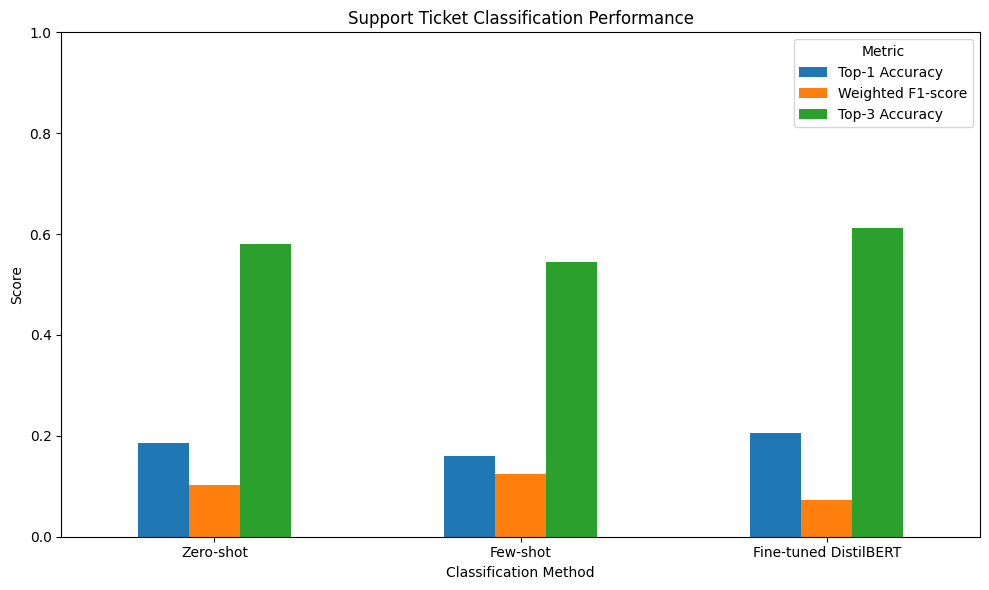

In [72]:
import matplotlib.pyplot as plt

comparison_plot_df = comparison_df.set_index("Method")

ax = comparison_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Support Ticket Classification Performance")
plt.xlabel("Classification Method")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
def predict_top_3_tags(ticket_text):
    model.eval()

    inputs = tokenizer(
        ticket_text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    device = next(model.parameters()).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output = model(**inputs)

    probabilities = torch.softmax(
        output.logits,
        dim=1
    )[0].cpu().numpy()

    top3_ids = np.argsort(probabilities)[-3:][::-1]

    results = []

    for rank, label_id in enumerate(top3_ids, start=1):
        results.append({
            "Rank": rank,
            "Tag": id2label[int(label_id)],
            "Probability": float(probabilities[label_id])
        })

    return pd.DataFrame(results)

In [74]:
new_ticket = """
I was charged twice for my subscription and I want the extra
payment returned.
"""

predict_top_3_tags(new_ticket)

,Rank,Tag,Probability
0,1,Technical issue,0.209861
1,2,Refund request,0.205971
2,3,Cancellation request,0.200942


In [75]:
new_ticket = """
The application closes every time I try to upload a document.
"""

predict_top_3_tags(new_ticket)

,Rank,Tag,Probability
0,1,Technical issue,0.206783
1,2,Refund request,0.202561
2,3,Cancellation request,0.201928


In [76]:
comparison_df.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


In [77]:
import json
import os

model_folder = "support_ticket_classifier"

trainer.save_model(model_folder)
tokenizer.save_pretrained(model_folder)

with open(
    os.path.join(model_folder, "label_mapping.json"),
    "w"
) as file:
    json.dump(
        {
            "label2id": label2id,
            "id2label": id2label
        },
        file,
        indent=4
    )

print("Model saved inside:", model_folder)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved inside: support_ticket_classifier


In [78]:
import shutil

shutil.make_archive(
    "support_ticket_classifier",
    "zip",
    model_folder
)

print("ZIP file created: support_ticket_classifier.zip")

ZIP file created: support_ticket_classifier.zip


In [79]:
from google.colab import files

files.download("support_ticket_classifier.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
files.download("final_model_comparison.csv")
files.download("fine_tuned_results.csv")
files.download("model_performance_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>